<a href="https://colab.research.google.com/github/khoihole329-sudo/Minhkhoi/blob/main/L%C3%80M%20S%E1%BA%A0CH%20D%E1%BB%AE%20LI%E1%BB%86U%20C%C6%A0%20B%E1%BA%A2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cat and dog

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path: /kaggle/input/cat-and-dog


In [4]:
import os

print(os.listdir(path))

['test_set', 'training_set']


In [7]:
train_dir = os.path.join(path, "training_set", "training_set")
test_dir = os.path.join(path, "test_set", "test_set")

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['dogs', 'cats']
Test folders: ['dogs', 'cats']


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [9]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [10]:
train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Số ảnh train:", len(train_dataset))
print("Số ảnh test:", len(test_dataset))

Classes: ['cats', 'dogs']
Số ảnh train: 8005
Số ảnh test: 2023


In [11]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 x 128 x 128
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 16 x 64 x 64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 32 x 32 x 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # 64 x 16 x 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)                            # 2 lớp: cats, dogs
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CatDogCNN().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Tổng tham số: {n_params:,}")

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Tổng tham số: 2,121,122


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
def evaluate(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return loss_sum / total, correct / total

In [14]:
num_epochs = 10

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc*100:.2f}% "
        f"test_loss={test_loss:.4f} "
        f"test_acc={test_acc*100:.2f}%"
    )

Epoch 1/10 train_loss=0.6501 train_acc=61.01% test_loss=0.6006 test_acc=68.02%
Epoch 2/10 train_loss=0.5734 train_acc=69.98% test_loss=0.5294 test_acc=73.26%
Epoch 3/10 train_loss=0.5036 train_acc=75.29% test_loss=0.5235 test_acc=73.50%
Epoch 4/10 train_loss=0.4456 train_acc=78.61% test_loss=0.4902 test_acc=76.72%
Epoch 5/10 train_loss=0.4018 train_acc=81.57% test_loss=0.4732 test_acc=78.15%
Epoch 6/10 train_loss=0.3547 train_acc=84.31% test_loss=0.5031 test_acc=77.51%
Epoch 7/10 train_loss=0.2983 train_acc=87.25% test_loss=0.4949 test_acc=78.40%
Epoch 8/10 train_loss=0.2481 train_acc=89.47% test_loss=0.5516 test_acc=78.25%
Epoch 9/10 train_loss=0.1945 train_acc=92.07% test_loss=0.6302 test_acc=78.20%
Epoch 10/10 train_loss=0.1643 train_acc=93.27% test_loss=0.6788 test_acc=77.21%


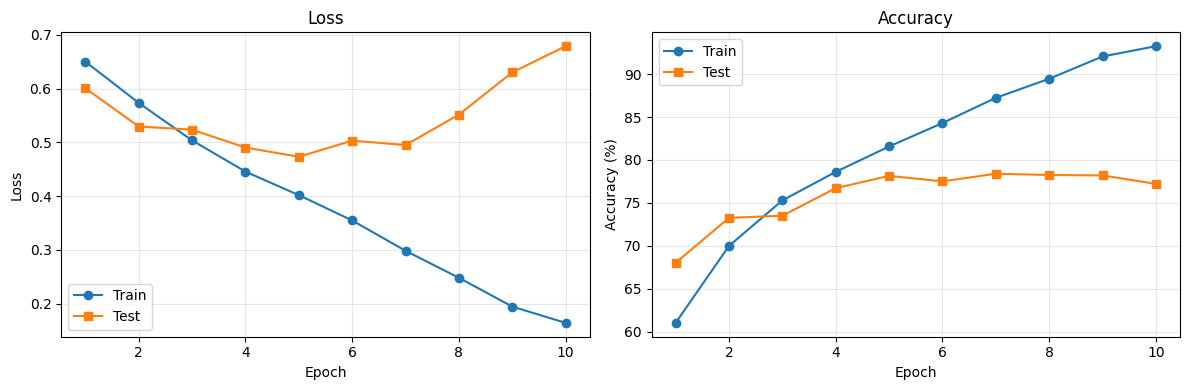

In [15]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss_history, 'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a * 100 for a in train_acc_history], 'o-', label='Train')
axes[1].plot(epochs, [a * 100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_acc = evaluate(model, test_loader)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc*100:.2f}%")

Final test loss: 0.6788
Final test accuracy: 77.21%


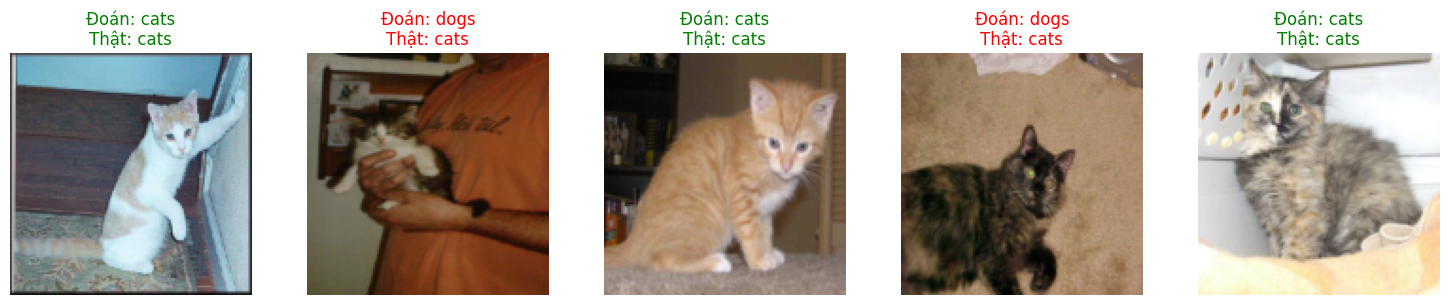

In [17]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

class_names = train_dataset.classes

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    img = images[i].cpu()
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0)

    color = "green" if preds[i] == labels[i] else "red"

    axes[i].imshow(img)
    axes[i].set_title(
        f"Đoán: {class_names[preds[i]]}\nThật: {class_names[labels[i]]}",
        color=color
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## CIFAR-10

In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [27]:
import kagglehub

path = kagglehub.dataset_download("ayush1220/cifar10")
print("Path:", path)

Using Colab cache for faster access to the 'cifar10' dataset.
Path: /kaggle/input/cifar10


In [28]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    if level < 3:
        print("\nROOT:", root)
        print("DIRS:", dirs)
        print("FILES:", files[:5])


ROOT: /kaggle/input/cifar10
DIRS: ['cifar10']
FILES: []

ROOT: /kaggle/input/cifar10/cifar10
DIRS: ['test', 'train']
FILES: []

ROOT: /kaggle/input/cifar10/cifar10/test
DIRS: ['airplane', 'horse', 'truck', 'automobile', 'ship', 'dog', 'bird', 'frog', 'cat', 'deer']
FILES: []

ROOT: /kaggle/input/cifar10/cifar10/train
DIRS: ['airplane', 'horse', 'truck', 'automobile', 'ship', 'dog', 'bird', 'frog', 'cat', 'deer']
FILES: []


In [29]:
train_dir = os.path.join(path, "cifar10", "train")
test_dir = os.path.join(path, "cifar10", "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train dir: /kaggle/input/cifar10/cifar10/train
Test dir: /kaggle/input/cifar10/cifar10/test
Train folders: ['airplane', 'horse', 'truck', 'automobile', 'ship', 'dog', 'bird', 'frog', 'cat', 'deer']
Test folders: ['airplane', 'horse', 'truck', 'automobile', 'ship', 'dog', 'bird', 'frog', 'cat', 'deer']


In [31]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [32]:
train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Số ảnh train:", len(train_dataset))
print("Số ảnh test:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Số ảnh train: 50000
Số ảnh test: 10000


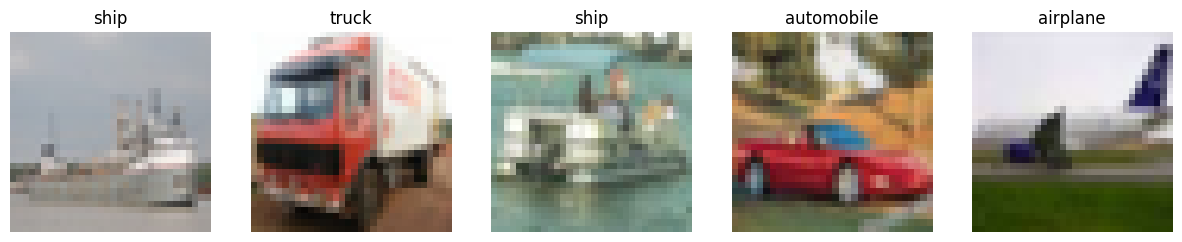

In [33]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    img = images[i]

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.show()

In [34]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 x 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 32 x 16 x 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 64 x 8 x 8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # 128 x 4 x 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)                           # 10 lớp CIFAR-10
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CIFAR10CNN().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Tổng tham số: {n_params:,}")

CIFAR10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Tổng tham số: 620,362


In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [36]:
def evaluate(model, loader):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return loss_sum / total, correct / total

In [37]:
num_epochs = 10

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc*100:.2f}% "
        f"test_loss={test_loss:.4f} "
        f"test_acc={test_acc*100:.2f}%"
    )

Epoch 1/10 train_loss=1.4884 train_acc=45.37% test_loss=1.0929 test_acc=61.19%
Epoch 2/10 train_loss=1.0743 train_acc=61.87% test_loss=0.9479 test_acc=66.49%
Epoch 3/10 train_loss=0.8989 train_acc=68.34% test_loss=0.8450 test_acc=70.52%
Epoch 4/10 train_loss=0.7787 train_acc=72.68% test_loss=0.7505 test_acc=73.81%
Epoch 5/10 train_loss=0.7047 train_acc=75.27% test_loss=0.7346 test_acc=74.60%
Epoch 6/10 train_loss=0.6267 train_acc=78.08% test_loss=0.7097 test_acc=75.90%
Epoch 7/10 train_loss=0.5799 train_acc=79.67% test_loss=0.7091 test_acc=76.19%
Epoch 8/10 train_loss=0.5261 train_acc=81.36% test_loss=0.7247 test_acc=76.71%
Epoch 9/10 train_loss=0.4811 train_acc=82.84% test_loss=0.7665 test_acc=76.23%
Epoch 10/10 train_loss=0.4420 train_acc=84.35% test_loss=0.7626 test_acc=76.54%


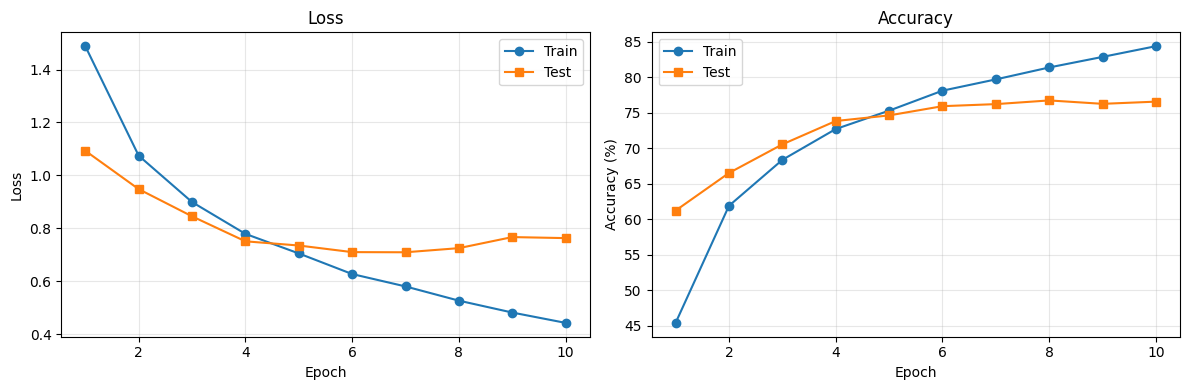

In [39]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss_history, 'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a * 100 for a in train_acc_history], 'o-', label='Train')
axes[1].plot(epochs, [a * 100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
test_loss, test_acc = evaluate(model, test_loader)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc*100:.2f}%")

Final test loss: 0.7626
Final test accuracy: 76.54%


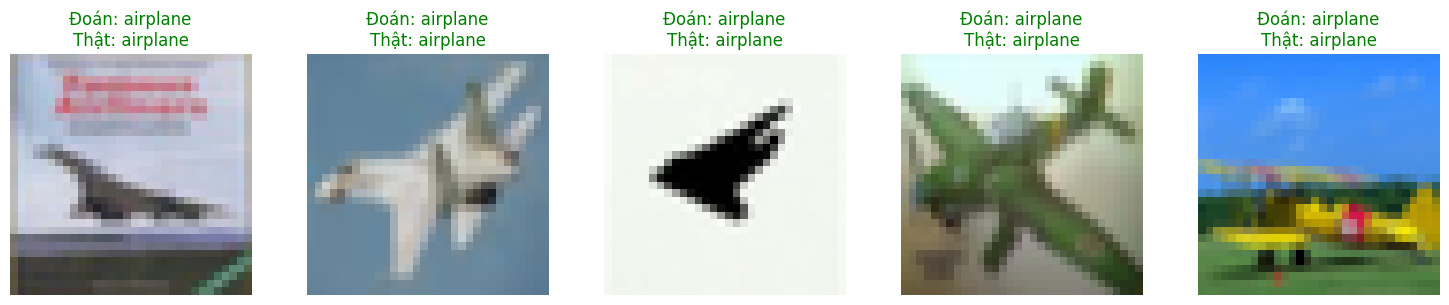

In [41]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    img = images[i].cpu()

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    color = "green" if preds[i] == labels[i] else "red"

    axes[i].imshow(img)
    axes[i].set_title(
        f"Đoán: {class_names[preds[i]]}\nThật: {class_names[labels[i]]}",
        color=color
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()